# Analyse Exploratoire — Crimes et Délits

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/frederic/Documents/Jedha/Jedha/02_Data Science and Eng - Fullstack - Full-Time/X_Projects/Project_Oasis/oasis-security-complete/data/crimes-et-délits-PN-GN.xlsx"
df = pd.read_excel(path)

df = df.iloc[2:]
df = df.rename(columns={
    df.columns[0]:"annee",
    df.columns[1]:"code",
    df.columns[2]:"crime"
})

df_long = df.melt(
    id_vars=["annee","code","crime"],
    var_name="departement",
    value_name="nb"
)

df_long = df_long.dropna(subset=["nb"])
df_long["nb"] = pd.to_numeric(df_long["nb"], errors="coerce")
df_long = df_long.dropna()

df_long.head()


,annee,code,crime,departement,nb
0,Année 2012 - services de police,1,Règlements de compte entre malfaireurs,01,0.0
1,Année 2012 - services de police,2,Homicides pour voler et à l'occasion de vols,01,0.0
2,Année 2012 - services de police,3,Homicides pour d'autres motifs,01,0.0
3,Année 2012 - services de police,4,Tentatives d'homicides pour voler et à l'occas...,01,0.0
4,Année 2012 - services de police,5,Tentatives homicides pour d'autres motifs,01,0.0


## Distribution globale

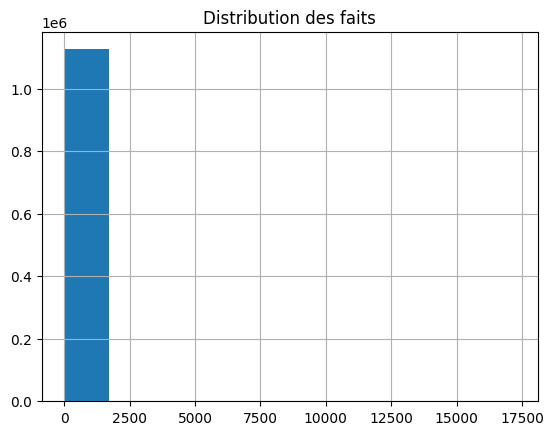

In [10]:

df_long["nb"].hist()
plt.title("Distribution des faits")
plt.show()


## Crimes les plus fréquents

In [12]:
df_long.groupby("crime")["nb"].sum().sort_values(ascending=False).head(15)

crime
Autres vols simples contre des particuliers dans des locaux ou lieux publics    3342820.0
Vols à la roulotte                                                              2586123.0
Autres coups et blessures volontaires criminels ou correctionnels               2436894.0
Escroqueries et abus de confiance                                               2238067.0
Cambriolages de locaux d'habitations principales                                2157769.0
Autres vols simples contre des particuliers dans  deslocaux privés              1873313.0
Usage de stupéfiants                                                            1727518.0
Vols à la tire                                                                  1317596.0
Autres délits                                                                   1248000.0
Autres destructions er dégradations de biens privés                             1121396.0
Menaces ou chantages dans un autre but                                          1073885.0
Vols

## Evolution temporelle

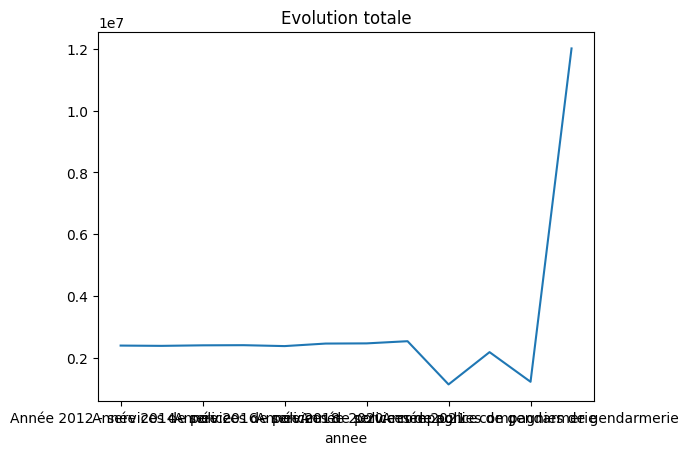

In [13]:

evo = df_long.groupby("annee")["nb"].sum()
evo.plot()
plt.title("Evolution totale")
plt.show()


## Top villes

In [17]:
df_long.groupby("departement")["nb"].sum().sort_values(ascending=False).head(15)

departement
75.14    281678.0
31.2     181323.0
35.3     174090.0
62.10    163134.0
75.11    154193.0
75.12    146038.0
35.5     142976.0
53       142823.0
38.3     141789.0
80.1     139515.0
14.2     136114.0
06.8     135599.0
14.3     133584.0
45.2     133067.0
71.3     132672.0
Name: nb, dtype: float64

## Heatmap crimes vs années

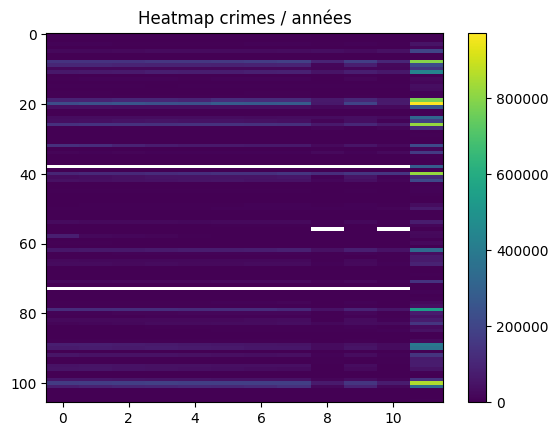

In [18]:

pivot = df_long.pivot_table(index="crime", columns="annee", values="nb", aggfunc="sum")
plt.imshow(pivot, aspect="auto")
plt.title("Heatmap crimes / années")
plt.colorbar()
plt.show()
